# Exp 9: capped vs. uncapped NPM priority index

exp_9 re-solves every exp_8 instance with `strategy="network_prioritized_uncapped"` (priority index `σ_t / (n_t + ε_t)`), versus exp_8's original capped index `σ_t / min(K, n_t + ε_t)`. exp_9 does not re-run the exact solver, so optimality gaps are computed against exp_8's exact profits, joined on `(job_id, run_index)`.

The join is only valid if the instances are identical, not merely similar -- this is verified below. exp_9 also includes commit `e0f94ed`'s epsilon tie-breaking, which exp_8's NPM predates; we check below that it never actually fires, so the comparison isolates the cap alone.

## Summary of findings

- **Clean comparison**: all 1,959 joined runs are identical instances between exp_8 and exp_9, and epsilon tie-breaking never fires, so the only difference is the cap.
- **Hard-instance failure rate drops from 27.7% to 8.1%** (383 instances where the true optimum beats the efficient matching; the only ones where NPM can fail at all). Failures above a 10% gap drop from 11.0% to 2.1%.
- **Paired: 76 runs fixed, 1 broken, 4 improved, 0 worsened, 26 unchanged.** The one regression is `job_114/run_7` (0% → 3.7%).
- **All 26 unchanged failures have identical selections under both indices** -- both indices rank some intermediary the optimum doesn't use ahead of one it needs, so both reach the same wrong set. This is still an ordering problem (a different ordering could reach the optimum), not an unreachable one; see the failure analysis in `exp_10_results.ipynb`. Not individually verified for all 26.
- **Runtime is unchanged** (mean 34s vs. 37s; oracle calls ~5 either way).

In [1]:
from pathlib import Path
import gzip
import json
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

In [2]:
sns.set_theme(context="paper", style="ticks")
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

VARIANT_ORDER = ["Capped", "Uncapped"]
VARIANT_COLORS = dict(zip(VARIANT_ORDER, sns.color_palette()[1:3]))
ZERO_TOL = 1e-9          # relative gaps below this are floating-point noise
NONTRIVIAL_TOL = 1.0     # currency units; matches BRANCH_PRUNE_TOL in the solver
FIG_DIR = Path("../figures/exp_9")

## Load and join

In [3]:
def load_runs(experiment: str) -> dict:
    runs = {}
    for file in Path(f"../results/{experiment}").rglob("*.json.gz"):
        with gzip.open(file, "rt", encoding="utf-8") as f:
            payload = json.load(f)
        for run in payload["runs"]:
            runs[(payload["experiment_metadata"]["job_id"], run["metadata"]["run_index"])] = run
    return runs

exp8 = load_runs("exp_8")
exp9 = load_runs("exp_9")

common = sorted(set(exp8) & set(exp9))
print(f"exp_8 runs: {len(exp8)}, exp_9 runs: {len(exp9)}, joined: {len(common)}")
print(f"dropped (exp_9 only, no exact baseline): {sorted(set(exp9) - set(exp8))}")
print(f"dropped (exp_8 only): {sorted(set(exp8) - set(exp9))}")

exp_8 runs: 1959, exp_9 runs: 1960, joined: 1959
dropped (exp_9 only, no exact baseline): [(116, 9)]
dropped (exp_8 only): []


### Verify the instances are identical

exp_8 and exp_9 share `BASE_SEED` and the same perturbation/sampling code, so each `(job_id, run_index)` should reproduce the same instance exactly. If any of these counts is nonzero, the joined gaps below are not trustworthy.

In [4]:
def farmer_quantities(summary):
    return {f["id"]: f["quantity"] for f in summary["instance_snapshot"]["farmers"]}

def dicts_close(a, b):
    return a.keys() == b.keys() and all(math.isclose(a[k], b[k]) for k in a)

mismatches = Counter()
for key in common:
    a, b = exp8[key], exp9[key]
    pa, pb = a["summary_exact"]["params"], b["summary_npm"]["params"]
    mismatches["instance_file"] += a["metadata"]["instance_file"] != b["metadata"]["instance_file"]
    mismatches["optimizer_seed"] += a["metadata"]["optimizer_seed"] != b["metadata"]["optimizer_seed"]
    mismatches["het_costs"] += not dicts_close(pa["het_costs"], pb["het_costs"])
    mismatches["epsilons"] += not dicts_close(pa["epsilons"], pb["epsilons"])
    mismatches["farmer_quantities"] += farmer_quantities(a["summary_exact"]) != farmer_quantities(b["summary_npm"])

print(dict(mismatches))
assert sum(mismatches.values()) == 0, 'exp_8 and exp_9 instances differ -- joined gaps are invalid'


{'instance_file': 0, 'optimizer_seed': 0, 'het_costs': 0, 'epsilons': 0, 'farmer_quantities': 0}


### Verify epsilon tie-breaking never fires

exp_9's NPM breaks priority-score ties by descending `ε_t`; exp_8's did not. If no run has two intermediaries with exactly equal scores, the tie-break is a no-op and exp_8 vs. exp_9 differs *only* in the cap.

In [5]:
def priority_scores(summary, capped: bool):
    params = summary["params"]
    K = summary["instance_snapshot"]["constants"]["truck_capacity_tons"]
    n = Counter()
    for farmer in summary["instance_snapshot"]["farmers"]:
        n[farmer["intermediary_id"]] += farmer["quantity"]
    scores = []
    for iid, sigma in params["het_costs"].items():
        denom = max(n[iid] + params["epsilons"][iid], 1e-4)
        scores.append(sigma / (min(K, denom) if capped else denom))
    return sorted(scores)

def has_tie(scores):
    return any(abs(a - b) <= 1e-9 * max(1.0, abs(a)) for a, b in zip(scores, scores[1:]))

for capped in (True, False):
    n_ties = sum(has_tie(priority_scores(exp9[k]["summary_npm"], capped)) for k in common)
    print(f"{'capped' if capped else 'uncapped'}: runs with any exact score tie = {n_ties} / {len(common)}")

capped: runs with any exact score tie = 0 / 1959
uncapped: runs with any exact score tie = 0 / 1959


### Build the per-run table

In [6]:
def primary(summary):
    return summary["platform_solve_result"]["primary_result"]

def rel_gap(exact, profit):
    # platform profit can be negative, so normalize by |exact| to keep the sign meaningful
    return (exact - profit) / abs(exact) if exact != 0 else np.nan

rows = []
for job_id, run_index in common:
    a, b = exp8[(job_id, run_index)], exp9[(job_id, run_index)]
    exact = primary(a["summary_exact"])
    capped = primary(a["summary_npm"])
    uncapped = primary(b["summary_npm"])
    exact_profit = exact["platform_profit"]
    rows.append({
        "job_id": job_id,
        "run_index": run_index,
        "instance_file": a["metadata"]["instance_file"],
        "n_farmers": len(a["summary_exact"]["instance_snapshot"]["farmers"]),
        "exact_profit": exact_profit,
        "capped_profit": capped["platform_profit"],
        "uncapped_profit": uncapped["platform_profit"],
        "capped_gap": rel_gap(exact_profit, capped["platform_profit"]),
        "uncapped_gap": rel_gap(exact_profit, uncapped["platform_profit"]),
        "capped_matches_exact": set(capped["selected_intermediaries"]) == set(exact["selected_intermediaries"]),
        "uncapped_matches_exact": set(uncapped["selected_intermediaries"]) == set(exact["selected_intermediaries"]),
        "exact_time": a["summary_exact"]["total_time"],
        "capped_time": a["summary_npm"]["total_time"],
        "uncapped_time": b["summary_npm"]["total_time"],
        "capped_oracle_calls": a["summary_npm"]["total_oracle_calls"],
        "uncapped_oracle_calls": b["summary_npm"]["total_oracle_calls"],
        # true optimum strictly beats the efficient (min-cost) matching: the only
        # instances where either NPM variant can have a nonzero gap at all
        "is_hard": exact_profit - a["summary_exact"]["forced_lower_bound"] > NONTRIVIAL_TOL,
    })

df = pd.DataFrame(rows)
df.shape

(1959, 17)

In [7]:
# sanity check: neither NPM variant should ever beat exact
print("Negative gaps (variant beats exact):")
print(df.query("capped_gap < -1e-6 or uncapped_gap < -1e-6")[["job_id", "run_index", "capped_gap", "uncapped_gap"]])

# clip floating-point noise below zero
for col in ["capped_gap", "uncapped_gap"]:
    df[col] = df[col].clip(lower=0)

# long format for plotting
long_df = pd.concat([
    df.assign(variant="Capped", gap=df["capped_gap"], time=df["capped_time"]),
    df.assign(variant="Uncapped", gap=df["uncapped_gap"], time=df["uncapped_time"]),
], ignore_index=True)

Negative gaps (variant beats exact):
Empty DataFrame
Columns: [job_id, run_index, capped_gap, uncapped_gap]
Index: []


## Headline: failure rates, all runs vs. hard instances

As established in the exp_8 analysis, NPM's `k=0` candidate always equals the efficient matching, so a nonzero gap is only possible on "hard" instances (true optimum beats the efficient matching). This holds for both variants, since uncapping only reorders which candidates are tried after `k=0`. Rates over *all* runs dilute the failure rate with instances where failure is impossible, so the hard-only rows are the meaningful ones.

In [8]:
THRESHOLDS = [ZERO_TOL, 1e-3, 1e-2, 0.05, 0.10]

def threshold_row(gaps):
    return {f"gap > {t:.1%}": (gaps > t).mean() for t in THRESHOLDS} | {"n": len(gaps)}

hard = df.query("is_hard")
threshold_table = pd.DataFrame({
    "Capped (all runs)": threshold_row(df["capped_gap"]),
    "Uncapped (all runs)": threshold_row(df["uncapped_gap"]),
    "Capped (hard only)": threshold_row(hard["capped_gap"]),
    "Uncapped (hard only)": threshold_row(hard["uncapped_gap"]),
}).T
threshold_table["n"] = threshold_table["n"].astype(int)
print(f"hard instances: {len(hard)} of {len(df)} ({len(hard) / len(df):.1%})")
threshold_table

hard instances: 383 of 1959 (19.6%)


,gap > 0.0%,gap > 0.1%,gap > 1.0%,gap > 5.0%,gap > 10.0%,n
Capped (all runs),0.054109,0.053599,0.044410,0.028586,0.021440,1959
Uncapped (all runs),0.015824,0.015314,0.013272,0.005615,0.004084,1959
Capped (hard only),0.276762,0.274151,0.227154,0.146214,0.109661,383
Uncapped (hard only),0.080940,0.078329,0.067885,0.028721,0.020888,383


## Paired comparison: fixes vs. regressions

The aggregate rates can't distinguish "uncapping fixes some failures" from "uncapping fixes some failures and breaks others." Since every instance was solved both ways, compare them run by run.

In [9]:
def outcome(row):
    c, u = row["capped_gap"] > ZERO_TOL, row["uncapped_gap"] > ZERO_TOL
    if not c and not u:
        return "both exact"
    if c and not u:
        return "fixed by uncapping"
    if not c and u:
        return "broken by uncapping"
    if row["uncapped_gap"] < row["capped_gap"] - ZERO_TOL:
        return "both fail, uncapped better"
    if row["uncapped_gap"] > row["capped_gap"] + ZERO_TOL:
        return "both fail, uncapped worse"
    return "both fail, same gap"

df["outcome"] = df.apply(outcome, axis=1)
outcome_order = [
    "both exact", "fixed by uncapping", "broken by uncapping",
    "both fail, uncapped better", "both fail, uncapped worse", "both fail, same gap",
]
outcome_table = (
    df.groupby("is_hard")["outcome"].value_counts()
    .unstack(fill_value=0)
    .reindex(columns=outcome_order, fill_value=0)
    .rename(index={False: "easy (true opt = efficient)", True: "hard"})
)
outcome_table.loc["total"] = outcome_table.sum()
outcome_table

outcome,both exact,fixed by uncapping,broken by uncapping,"both fail, uncapped better","both fail, uncapped worse","both fail, same gap"
is_hard,,,,,,
easy (true opt = efficient),1576,0,0,0,0,0
hard,276,76,1,4,0,26
total,1852,76,1,4,0,26


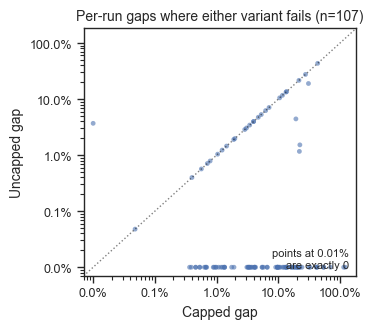

In [10]:
fig, ax = plt.subplots(figsize=(3.8, 3.4))

failed = df.query("capped_gap > @ZERO_TOL or uncapped_gap > @ZERO_TOL")
# plot exact zeros at a floor so they're visible on log axes
floor = 1e-4
x = failed["capped_gap"].clip(lower=floor)
y = failed["uncapped_gap"].clip(lower=floor)
ax.scatter(x, y, s=12, alpha=0.6, color=sns.color_palette()[0], edgecolor="none")

lims = [floor * 0.7, max(x.max(), y.max()) * 1.5]
ax.plot(lims, lims, color="black", linestyle="dotted", linewidth=1, alpha=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
ax.set_xlabel("Capped gap")
ax.set_ylabel("Uncapped gap")
ax.set_title(f"Per-run gaps where either variant fails (n={len(failed)})")
ax.text(lims[1] / 1.3, lims[0] * 1.3, f"points at {floor:.2%}\nare exactly 0",
        fontsize=8, ha="right", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "paired_gap_scatter.png", bbox_inches="tight", dpi=300)
plt.show()

## Gap distributions (nonzero gaps only)

Both distributions are dominated by exact zeros, so the histogram/CDF are restricted to nonzero gaps on a log axis.

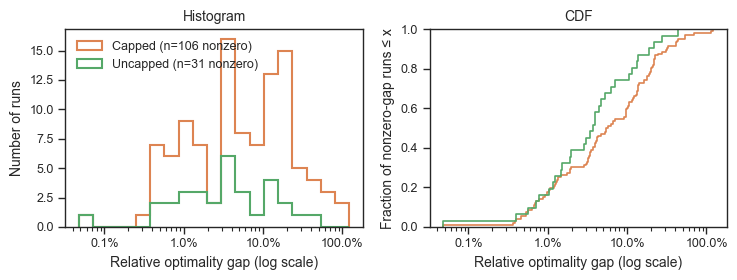

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 2.9))

nonzero = long_df.query("gap > @ZERO_TOL")
bins = np.logspace(np.log10(nonzero["gap"].min()), np.log10(nonzero["gap"].max()), 20)

for variant in VARIANT_ORDER:
    nz = nonzero.query("variant == @variant")
    label = f"{variant} (n={len(nz)} nonzero)"
    axes[0].hist(nz["gap"], bins=bins, histtype="step", linewidth=1.5,
                 color=VARIANT_COLORS[variant], label=label)
    axes[1].ecdf(nz["gap"], color=VARIANT_COLORS[variant], label=label)

for ax in axes:
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
    ax.set_xlabel("Relative optimality gap (log scale)")
axes[0].set_ylabel("Number of runs")
axes[0].set_title("Histogram")
axes[1].set_ylabel("Fraction of nonzero-gap runs \u2264 x")
axes[1].set_title("CDF")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "npm_gap_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

## Gap by instance size

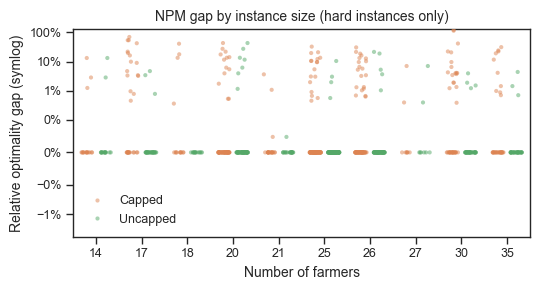

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 3))

sns.stripplot(
    data=long_df.query("is_hard"),
    x="n_farmers", y="gap",
    hue="variant", hue_order=VARIANT_ORDER, palette=VARIANT_COLORS,
    dodge=True, alpha=0.5, size=3, jitter=0.25, ax=ax,
)
ax.set_yscale("symlog", linthresh=1e-3)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlabel("Number of farmers")
ax.set_ylabel("Relative optimality gap (symlog)")
ax.set_title("NPM gap by instance size (hard instances only)")
ax.legend(title=None, frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "npm_gap_by_size.png", bbox_inches="tight", dpi=300)
plt.show()

In [13]:
# failure rate on hard instances, by size
(
    long_df.query("is_hard")
    .assign(failed=lambda d: d["gap"] > ZERO_TOL)
    .groupby(["n_farmers", "variant"])["failed"].agg(["mean", "size"])
    .unstack("variant")
)

mean             size         
variant      Capped  Uncapped Capped Uncapped
n_farmers                                    
14         0.187500  0.125000     16       16
17         0.516129  0.096774     31       31
18         0.285714  0.000000     14       14
20         0.213115  0.114754     61       61
21         0.142857  0.047619     21       21
25         0.184783  0.043478     92       92
26         0.294118  0.073529     68       68
27         0.250000  0.250000      8        8
30         0.461538  0.102564     39       39
35         0.303030  0.090909     33       33

## Runtime

Uncapping changes the priority order, which can change how many candidates NPM evaluates before the `U_k` bound prunes the rest.

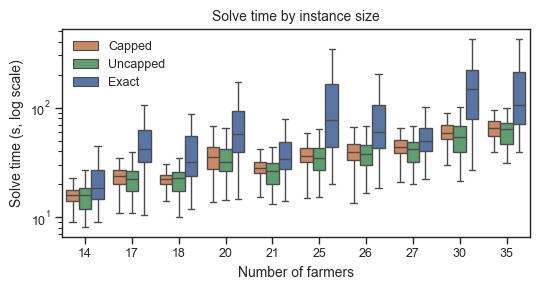

In [14]:
time_long = pd.concat([
    long_df[["n_farmers", "variant", "time"]],
    df[["n_farmers"]].assign(variant="Exact", time=df["exact_time"]),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(5.5, 3))
sns.boxplot(
    data=time_long, x="n_farmers", y="time",
    hue="variant", hue_order=VARIANT_ORDER + ["Exact"],
    palette=VARIANT_COLORS | {"Exact": sns.color_palette()[0]},
    showfliers=False, ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("Number of farmers")
ax.set_ylabel("Solve time (s, log scale)")
ax.set_title("Solve time by instance size")
ax.legend(title=None, frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "solve_time_by_size.png", bbox_inches="tight", dpi=300)
plt.show()

In [15]:
df[["capped_time", "uncapped_time", "capped_oracle_calls", "uncapped_oracle_calls"]].describe().loc[["mean", "50%", "max"]]

,capped_time,uncapped_time,capped_oracle_calls,uncapped_oracle_calls
mean,36.655360,34.305093,5.3073,5.12098
50%,33.830476,31.004112,6.0000,5.00000
max,110.863679,101.558563,10.0000,10.00000


## Remaining failures and regressions

The runs worth inspecting next: where uncapping still fails, and any runs it made worse.

In [16]:
cols = ["job_id", "run_index", "instance_file", "n_farmers", "capped_gap", "uncapped_gap", "outcome"]
print("Worst remaining uncapped failures:")
display(df.query("uncapped_gap > @ZERO_TOL").sort_values("uncapped_gap", ascending=False)[cols].head(10))

print("Runs made worse by uncapping:")
display(
    df.query("outcome in ['broken by uncapping', 'both fail, uncapped worse']")
    .sort_values("uncapped_gap", ascending=False)[cols]
)

Worst remaining uncapped failures:


,job_id,run_index,instance_file,n_farmers,capped_gap,uncapped_gap,outcome
1159,115,9,2020-08-28.yaml,20,0.434058,0.434058,"both fail, same gap"
739,73,9,2020-08-28.yaml,20,0.275285,0.275285,"both fail, same gap"
1462,146,3,2020-09-05.yaml,26,0.215768,0.215768,"both fail, same gap"
1525,152,6,2020-09-09.yaml,26,0.307810,0.189597,"both fail, uncapped better"
894,89,4,2020-08-28.yaml,20,0.135917,0.135917,"both fail, same gap"
1484,148,5,2020-08-30.yaml,14,0.133305,0.133305,"both fail, same gap"
982,98,2,2020-08-28.yaml,20,0.116725,0.116725,"both fail, same gap"
1701,170,2,2020-09-02.yaml,25,0.105203,0.105203,"both fail, same gap"
1282,128,3,2020-08-31.yaml,27,0.070816,0.070816,"both fail, same gap"
1157,115,7,2020-08-28.yaml,20,0.062306,0.062306,"both fail, same gap"


Runs made worse by uncapping:


,job_id,run_index,instance_file,n_farmers,capped_gap,uncapped_gap,outcome
1147,114,7,2020-09-09.yaml,26,0.0,0.036924,broken by uncapping
